# Logistic Regression: Классификация

Практическое применение логистической регрессии с использованием библиотеки `optimizer-playground`.

## Содержание
1. [Теория](#1-теория)
2. [Инфраструктура экспериментов](#2-инфраструктура-экспериментов)
3. [Бинарная классификация](#3-эксперимент-a--бинарная-классификация)
4. [Влияние порога решения](#4-эксперимент-b--влияние-порога-решения)
5. [Сравнение оптимизаторов](#5-эксперимент-c--сравнение-оптимизаторов)
6. [Mini-batch режим](#6-эксперимент-d--mini-batch-режим)
7. [Регуляризация](#7-эксперимент-e--регуляризация)
8. [Мультиклассовая классификация](#8-эксперимент-f--мультиклассовая-классификация)
9. [Сверка с sklearn](#9-сверка-с-sklearn)
10. [Финальные выводы](#10-финальные-выводы)

In [9]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.datasets import load_breast_cancer, load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve,
    average_precision_score,
    log_loss,
)
from sklearn.linear_model import (
    LogisticRegression as SklearnLogisticRegression,
)

from src.models import LogisticRegression
from src.optimizers.gd import GD
from src.optimizers.momentum import Momentum, NesterovMomentum
from src.optimizers.rmsprop import RMSProp
from src.optimizers.adam import Adam
from src.optimizers.adamw import AdamW
from src.regularizers import L2, L1

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 12

SEED = 42
np.random.seed(SEED)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


---
## 1. Теория

Логистическая регрессия — линейная модель в логит-пространстве:

$$z = Xw, \quad p(y=1|x) = \sigma(z) = \frac{1}{1+e^{-z}}$$

**Бинарный logloss** (в терминах логитов):
$$\mathcal{L} = \frac{1}{n}\sum_i \log(1+\exp(z_i)) - y_i z_i$$

**Мультикласс** (softmax + cross-entropy):
$$P(y=k|x) = \text{softmax}(XW)_k, \quad \mathcal{L} = -\frac{1}{n}\sum_i \sum_k y_{ik}\log p_{ik}$$

Стандартизация признаков критически важна для стабильной оптимизации.

---
## 2. Инфраструктура экспериментов

In [10]:
def make_splits(X, y, test_size=0.2, val_size=0.2, seed=SEED):
    X_temp, X_test, y_temp, y_test = train_test_split(
        X, y, test_size=test_size, random_state=seed, stratify=y
    )
    val_ratio = val_size / (1 - test_size)
    X_train, X_val, y_train, y_val = train_test_split(
        X_temp, y_temp, test_size=val_ratio, random_state=seed, stratify=y_temp
    )
    return X_train, X_val, X_test, y_train, y_val, y_test


def scale_X(X_train, X_val, X_test):
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_val_s = scaler.transform(X_val)
    X_test_s = scaler.transform(X_test)
    return X_train_s, X_val_s, X_test_s, scaler

In [11]:
def fit_eval_logreg(
    X_train,
    y_train,
    X_eval,
    y_eval,
    opt,
    reg=None,
    steps=1000,
    batch_size=None,
    seed=SEED,
    threshold=0.5,
):
    model = LogisticRegression(
        opt=opt,
        reg=reg,
        steps=steps,
        batch_size=batch_size,
        random_state=seed,
        fit_intercept=True,
    )
    model.fit(X_train, y_train)
    proba = model.predict_proba(X_eval)

    is_multiclass = False
    if proba.shape[1] > 2:
        is_multiclass = True

    if is_multiclass:
        y_proba = proba
        y_pred = np.argmax(proba, axis=1)
        precision = precision_score(
            y_eval, y_pred, average="macro", zero_division=0
        )
        recall = recall_score(y_eval, y_pred, average="macro", zero_division=0)
        f1 = f1_score(y_eval, y_pred, average="macro", zero_division=0)
        try:
            roc_auc = roc_auc_score(y_eval, y_proba, multi_class="ovr")
        except ValueError:
            roc_auc = float("nan")
    else:
        if proba.ndim == 2 and proba.shape[1] == 2:
            y_proba = proba[:, 1]
        else:
            y_proba = proba
        y_pred = (y_proba >= threshold).astype(int)
        precision = precision_score(y_eval, y_pred, zero_division=0)
        recall = recall_score(y_eval, y_pred, zero_division=0)
        f1 = f1_score(y_eval, y_pred, zero_division=0)
        try:
            roc_auc = roc_auc_score(y_eval, y_proba)
        except ValueError:
            roc_auc = float("nan")

    w = model.w
    if model.fit_intercept:
        w_no_intercept = w[1:]
    else:
        w_no_intercept = w
    w_norm = np.linalg.norm(w_no_intercept.flatten())

    return {
        "model": model,
        "history": model.history,
        "y_pred": y_pred,
        "y_proba": y_proba,
        "accuracy": accuracy_score(y_eval, y_pred),
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "roc_auc": roc_auc,
        "logloss": log_loss(y_eval, y_proba),
        "w_norm": w_norm,
    }

In [12]:
def grid_search_lr(
    X_train,
    y_train,
    X_val,
    y_val,
    opt_class,
    opt_kwargs,
    lr_grid,
    reg=None,
    steps=1000,
    batch_size=None,
    seed=SEED,
):
    results = []
    for lr in lr_grid:
        kwargs = opt_kwargs.copy()
        kwargs["lr"] = lr
        opt = opt_class(**kwargs)
        res = fit_eval_logreg(
            X_train, y_train, X_val, y_val, opt, reg, steps, batch_size, seed
        )
        results.append(
            {
                "lr": lr,
                "val_logloss": res["logloss"],
                "val_accuracy": res["accuracy"],
                "val_roc_auc": res["roc_auc"],
            }
        )
    df = pd.DataFrame(results)
    best_idx = df["val_logloss"].idxmin()
    best_lr = df.loc[best_idx, "lr"]
    return df, best_lr

---
## 3. Эксперимент A — Бинарная классификация

Датасет: `sklearn.datasets.load_breast_cancer()`

In [13]:
data = load_breast_cancer()
X, y = data.data, data.target
X_train, X_val, X_test, y_train, y_val, y_test = make_splits(X, y)
X_train_s, X_val_s, X_test_s, scaler = scale_X(X_train, X_val, X_test)
print(
    f"Train: {X_train_s.shape[0]}, Val: {X_val_s.shape[0]}, Test: {X_test_s.shape[0]}"
)
print(f"Features: {X_train_s.shape[1]}")

Train: 341, Val: 114, Test: 114
Features: 30


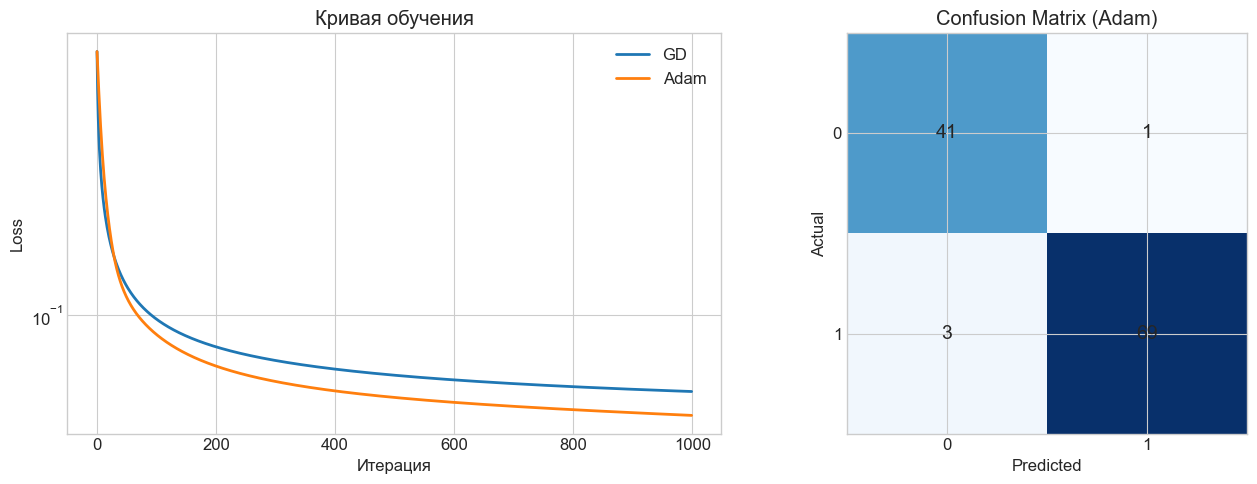

,Метрика,GD,Adam
0,Accuracy,0.964912,0.964912
1,Precision,0.985714,0.985714
2,Recall,0.958333,0.958333
3,F1,0.971831,0.971831
4,ROC-AUC,0.996032,0.993717
5,LogLoss,0.088616,0.086203


In [14]:
res_gd = fit_eval_logreg(
    X_train_s, y_train, X_test_s, y_test, GD(lr=0.1), steps=1000, seed=SEED
)
res_adam = fit_eval_logreg(
    X_train_s, y_train, X_test_s, y_test, Adam(lr=0.01), steps=1000, seed=SEED
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(res_gd["history"], label="GD", linewidth=2)
axes[0].plot(res_adam["history"], label="Adam", linewidth=2)
axes[0].set_xlabel("Итерация")
axes[0].set_ylabel("Loss")
axes[0].set_title("Кривая обучения")
axes[0].legend()
axes[0].set_yscale("log")

cm = confusion_matrix(y_test, res_adam["y_pred"])
axes[1].imshow(cm, cmap="Blues")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")
axes[1].set_title("Confusion Matrix (Adam)")
for i in range(2):
    for j in range(2):
        axes[1].text(j, i, cm[i, j], ha="center", va="center", fontsize=14)
axes[1].set_xticks([0, 1])
axes[1].set_yticks([0, 1])
plt.tight_layout()
plt.show()

metrics_df = pd.DataFrame(
    {
        "Метрика": [
            "Accuracy",
            "Precision",
            "Recall",
            "F1",
            "ROC-AUC",
            "LogLoss",
        ],
        "GD": [
            res_gd["accuracy"],
            res_gd["precision"],
            res_gd["recall"],
            res_gd["f1"],
            res_gd["roc_auc"],
            res_gd["logloss"],
        ],
        "Adam": [
            res_adam["accuracy"],
            res_adam["precision"],
            res_adam["recall"],
            res_adam["f1"],
            res_adam["roc_auc"],
            res_adam["logloss"],
        ],
    }
)
display(metrics_df)

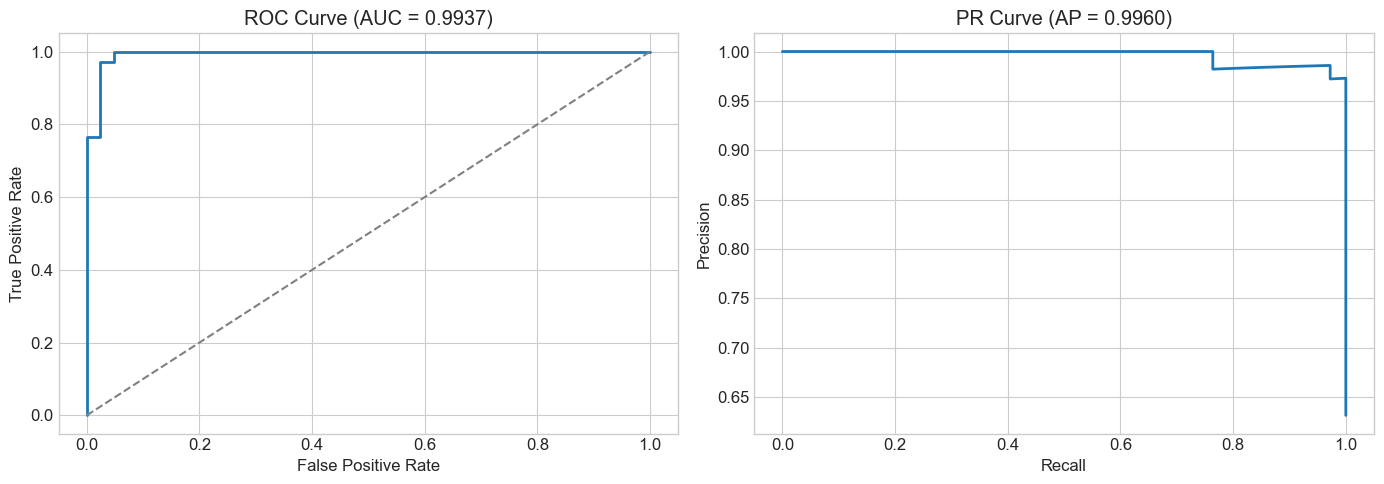

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fpr, tpr, _ = roc_curve(y_test, res_adam["y_proba"])
axes[0].plot(fpr, tpr, linewidth=2)
axes[0].plot([0, 1], [0, 1], linestyle="--", color="gray")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title(f"ROC Curve (AUC = {res_adam['roc_auc']:.4f})")

precision_vals, recall_vals, _ = precision_recall_curve(
    y_test, res_adam["y_proba"]
)
ap = average_precision_score(y_test, res_adam["y_proba"])
axes[1].plot(recall_vals, precision_vals, linewidth=2)
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title(f"PR Curve (AP = {ap:.4f})")
plt.tight_layout()
plt.show()

**Вывод:** Adam сходится быстрее GD. ROC-AUC > 0.99 указывает на высокое качество разделения классов.

---
## 4. Эксперимент B — Влияние порога решения

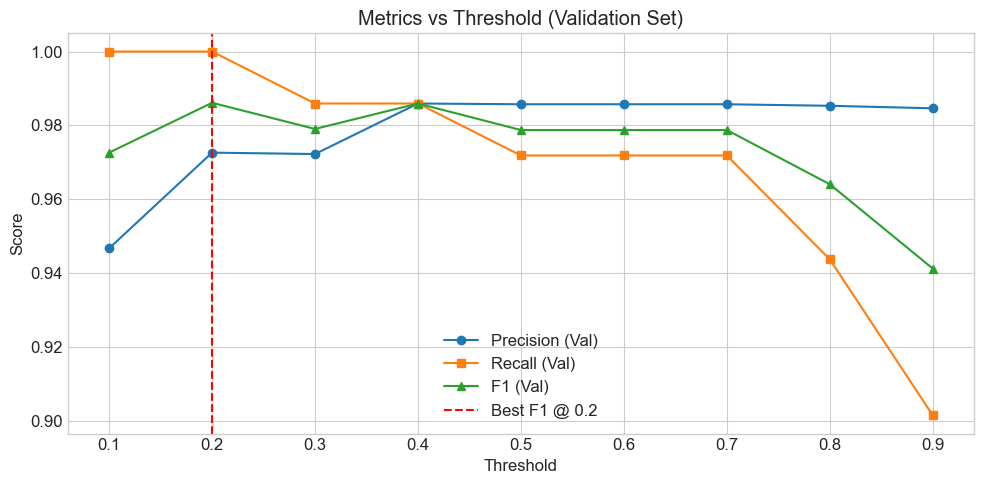

,threshold,precision,recall,f1
0,0.1,0.946667,1.000000,0.972603
1,0.2,0.972603,1.000000,0.986111
2,0.3,0.972222,0.985915,0.979021
3,0.4,0.985915,0.985915,0.985915
4,0.5,0.985714,0.971831,0.978723
5,0.6,0.985714,0.971831,0.978723
6,0.7,0.985714,0.971831,0.978723
7,0.8,0.985294,0.943662,0.964029
8,0.9,0.984615,0.901408,0.941176


Best Threshold (Val): 0.2
Test F1 (Default 0.5): 0.9718
Test F1 (Best Threshold): 0.9796


In [16]:
y_proba_val = res_adam["model"].predict_proba(X_val_s)
if y_proba_val.ndim == 2 and y_proba_val.shape[1] == 2:
    y_proba_val = y_proba_val[:, 1]

thresholds = np.arange(0.1, 1.0, 0.1)
threshold_results = []

for th in thresholds:
    y_pred_th = (y_proba_val >= th).astype(int)
    threshold_results.append(
        {
            "threshold": th,
            "precision": precision_score(y_val, y_pred_th, zero_division=0),
            "recall": recall_score(y_val, y_pred_th, zero_division=0),
            "f1": f1_score(y_val, y_pred_th, zero_division=0),
        }
    )

th_df = pd.DataFrame(threshold_results)
best_f1_idx = th_df["f1"].idxmax()
best_threshold = th_df.loc[best_f1_idx, "threshold"]

plt.figure(figsize=(10, 5))
plt.plot(
    th_df["threshold"], th_df["precision"], label="Precision (Val)", marker="o"
)
plt.plot(th_df["threshold"], th_df["recall"], label="Recall (Val)", marker="s")
plt.plot(th_df["threshold"], th_df["f1"], label="F1 (Val)", marker="^")
plt.axvline(
    best_threshold,
    color="red",
    linestyle="--",
    label=f"Best F1 @ {best_threshold:.1f}",
)
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Metrics vs Threshold (Validation Set)")
plt.legend()
plt.tight_layout()
plt.show()

display(th_df)

y_proba_test = res_adam["y_proba"]
y_pred_best = (y_proba_test >= best_threshold).astype(int)
y_pred_default = (y_proba_test >= 0.5).astype(int)

print(f"Best Threshold (Val): {best_threshold:.1f}")
print(f"Test F1 (Default 0.5): {f1_score(y_test, y_pred_default):.4f}")
print(f"Test F1 (Best Threshold): {f1_score(y_test, y_pred_best):.4f}")

**Вывод:** Оптимальный порог по F1 зависит от задачи. При снижении порога recall растёт, precision падает.

---
## 5. Эксперимент C — Сравнение оптимизаторов

In [17]:
lr_grid = [1e-4, 3e-4, 1e-3, 3e-3, 1e-2, 3e-2, 1e-1]
optimizers_config = {
    "GD": (GD, {}),
    "Momentum": (Momentum, {"momentum": 0.9}),
    "Nesterov": (NesterovMomentum, {"momentum": 0.9}),
    "RMSProp": (RMSProp, {"beta": 0.9}),
    "Adam": (Adam, {"beta_2": 0.99}),
    "AdamW": (AdamW, {"beta_2": 0.99, "weight_decay": 0.001}),
}
opt_results = []
for name, (opt_class, opt_kwargs) in optimizers_config.items():
    df, best_lr = grid_search_lr(
        X_train_s,
        y_train,
        X_val_s,
        y_val,
        opt_class,
        opt_kwargs,
        lr_grid,
        steps=1000,
    )
    kwargs = opt_kwargs.copy()
    kwargs["lr"] = best_lr
    res = fit_eval_logreg(
        X_train_s, y_train, X_test_s, y_test, opt_class(**kwargs), steps=1000
    )
    opt_results.append(
        {
            "Optimizer": name,
            "best_lr": best_lr,
            "test_accuracy": res["accuracy"],
            "test_roc_auc": res["roc_auc"],
            "test_logloss": res["logloss"],
            "history": res["history"],
        }
    )
opt_df = pd.DataFrame(
    [{k: v for k, v in r.items() if k != "history"} for r in opt_results]
)
display(opt_df)

,Optimizer,best_lr,test_accuracy,test_roc_auc,test_logloss
0,GD,0.100,0.964912,0.996032,0.088616
1,Momentum,0.030,0.956140,0.994709,0.084840
2,Nesterov,0.030,0.956140,0.994709,0.084689
3,RMSProp,0.001,0.964912,0.995040,0.086529
4,Adam,0.003,0.964912,0.994048,0.086329
5,AdamW,0.003,0.964912,0.994048,0.086334


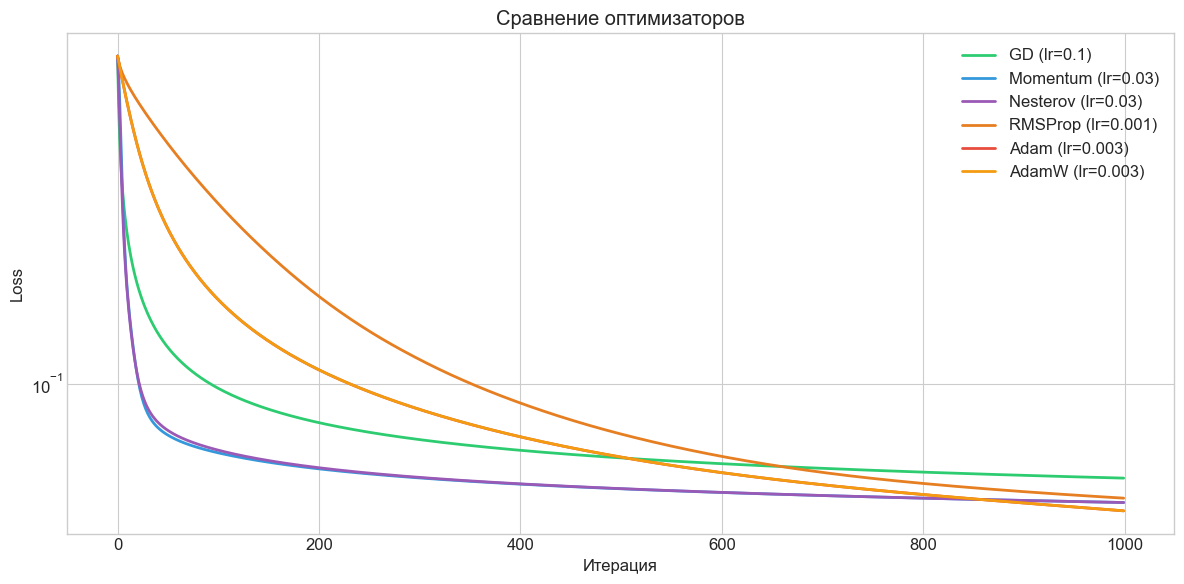

In [18]:
plt.figure(figsize=(12, 6))
colors = ["#2ecc71", "#3498db", "#9b59b6", "#e67e22", "#e74c3c", "#f39c12"]
for i, r in enumerate(opt_results):
    plt.plot(
        r["history"],
        label=f"{r['Optimizer']} (lr={r['best_lr']})",
        color=colors[i],
        linewidth=2,
    )
plt.xlabel("Итерация")
plt.ylabel("Loss")
plt.title("Сравнение оптимизаторов")
plt.legend()
plt.yscale("log")
plt.tight_layout()
plt.show()

**Вывод:** При правильном lr все оптимизаторы достигают сопоставимого качества. Adam менее чувствителен к выбору lr.

---
## 6. Эксперимент D — Mini-batch режим

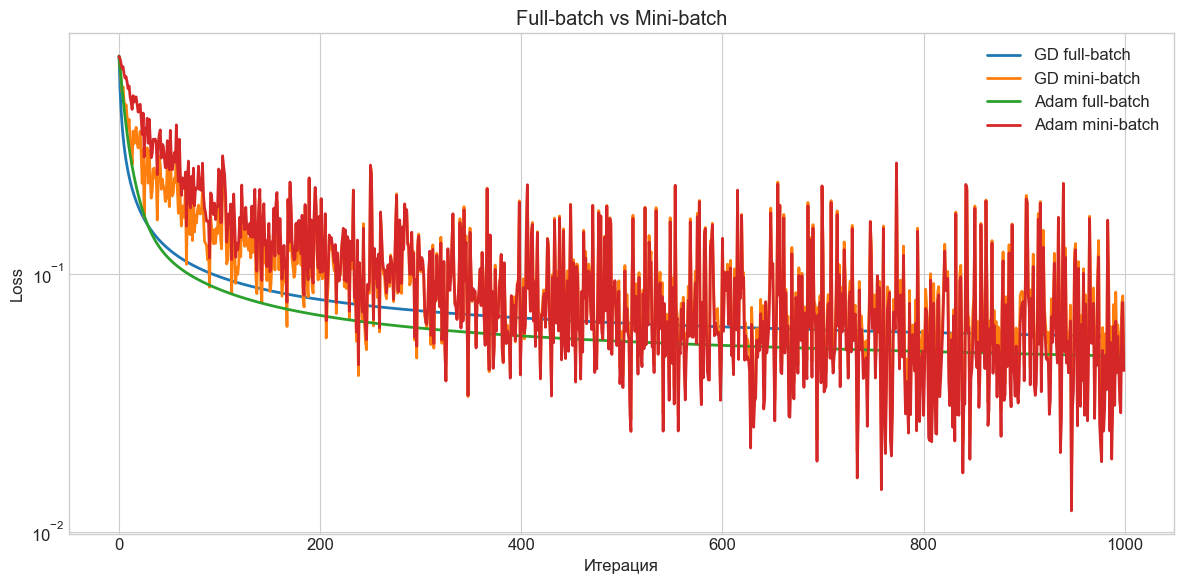

,Config,accuracy,roc_auc,logloss
0,GD full-batch,0.964912,0.996032,0.088616
1,GD mini-batch,0.982456,0.996032,0.101005
2,Adam full-batch,0.964912,0.993717,0.086203
3,Adam mini-batch,0.973684,0.995701,0.094625


In [19]:
batch_configs = {
    "GD full-batch": (GD(lr=0.1), None),
    "GD mini-batch": (GD(lr=0.03), 32),
    "Adam full-batch": (Adam(lr=0.01), None),
    "Adam mini-batch": (Adam(lr=0.003), 32),
}
batch_results = []
for name, (opt, bs) in batch_configs.items():
    res = fit_eval_logreg(
        X_train_s, y_train, X_test_s, y_test, opt, steps=1000, batch_size=bs
    )
    batch_results.append(
        {
            "Config": name,
            "accuracy": res["accuracy"],
            "roc_auc": res["roc_auc"],
            "logloss": res["logloss"],
            "history": res["history"],
        }
    )

plt.figure(figsize=(12, 6))
for r in batch_results:
    plt.plot(r["history"], label=r["Config"], linewidth=2)
plt.xlabel("Итерация")
plt.ylabel("Loss")
plt.title("Full-batch vs Mini-batch")
plt.legend()
plt.yscale("log")
plt.tight_layout()
plt.show()

batch_df = pd.DataFrame(
    [{k: v for k, v in r.items() if k != "history"} for r in batch_results]
)
display(batch_df)

**Вывод:** Mini-batch вносит шум в кривую loss, но работает при уменьшенном lr.

---
## 7. Эксперимент E — Регуляризация

In [20]:
reg_results = []
for alpha in [0.0, 1e-4, 1e-3, 1e-2, 1e-1]:
    reg = None if alpha == 0 else L2(alpha)
    reg_name = "None" if alpha == 0 else f"L2({alpha})"
    res = fit_eval_logreg(
        X_train_s, y_train, X_val_s, y_val, Adam(lr=0.01), reg=reg, steps=1000
    )
    reg_results.append(
        {
            "Regularizer": reg_name,
            "alpha": alpha,
            "val_accuracy": res["accuracy"],
            "val_roc_auc": res["roc_auc"],
            "val_logloss": res["logloss"],
            "w_norm": res["w_norm"],
        }
    )

for alpha in [1e-3, 1e-2, 1e-1]:
    res = fit_eval_logreg(
        X_train_s,
        y_train,
        X_val_s,
        y_val,
        Adam(lr=0.01),
        reg=L1(alpha),
        steps=1000,
    )
    w = res["model"].w[1:].flatten()
    sparsity = np.sum(np.abs(w) < 1e-6) / len(w)
    reg_results.append(
        {
            "Regularizer": f"L1({alpha})",
            "alpha": alpha,
            "val_accuracy": res["accuracy"],
            "val_roc_auc": res["roc_auc"],
            "val_logloss": res["logloss"],
            "w_norm": res["w_norm"],
            "sparsity": sparsity,
        }
    )

reg_df = pd.DataFrame(reg_results)
display(reg_df)


best_idx = reg_df["val_logloss"].idxmin()
best_row = reg_df.loc[best_idx]
print(
    f"Best Regularizer: {best_row['Regularizer']} with Val LogLoss: {best_row['val_logloss']:.4f}"
)

if "L2" in best_row["Regularizer"]:
    best_reg = L2(best_row["alpha"])
elif "L1" in best_row["Regularizer"]:
    best_reg = L1(best_row["alpha"])
else:
    best_reg = None

final_res = fit_eval_logreg(
    X_train_s,
    y_train,
    X_test_s,
    y_test,
    Adam(lr=0.01),
    reg=best_reg,
    steps=1000,
)
print(f"Test ROC-AUC: {final_res['roc_auc']:.4f}")
print(f"Test Accuracy: {final_res['accuracy']:.4f}")

,Regularizer,alpha,val_accuracy,val_roc_auc,val_logloss,w_norm,sparsity
0,None,0.0000,0.973684,0.997380,0.060422,4.548782,NaN
1,L2(0.0001),0.0001,0.973684,0.997380,0.059894,4.383038,NaN
2,L2(0.001),0.0010,0.982456,0.998035,0.060346,3.448394,NaN
3,L2(0.01),0.0100,0.973684,0.997380,0.096131,1.864326,NaN
4,L2(0.1),0.1000,0.938596,0.994432,0.191324,0.861251,NaN
5,L1(0.001),0.0010,0.973684,0.997380,0.060388,4.532378,0.0
6,L1(0.01),0.0100,0.973684,0.997380,0.060170,4.389066,0.0
7,L1(0.1),0.1000,0.982456,0.997707,0.063899,3.352430,0.1


Best Regularizer: L2(0.0001) with Val LogLoss: 0.0599
Test ROC-AUC: 0.9937
Test Accuracy: 0.9649


**Вывод:** L2 уменьшает норму весов. L1 способствует разреженности, но может снижать качество.

---
## 8. Эксперимент F — Мультиклассовая классификация

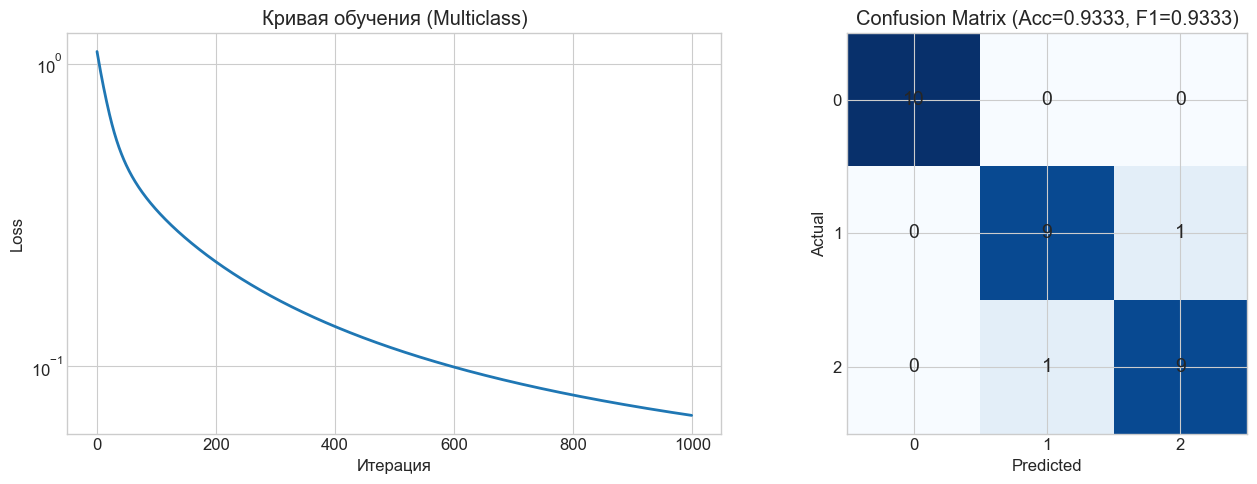

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



In [21]:
iris = load_iris()
X_iris, y_iris = iris.data, iris.target
X_tr_i, X_v_i, X_te_i, y_tr_i, y_v_i, y_te_i = make_splits(X_iris, y_iris)
X_tr_is, X_v_is, X_te_is, _ = scale_X(X_tr_i, X_v_i, X_te_i)

model_mc = LogisticRegression(opt=Adam(lr=0.01), steps=1000, random_state=SEED)
model_mc.fit(X_tr_is, y_tr_i)
y_pred_mc = model_mc.predict(X_te_is)
acc_mc = accuracy_score(y_te_i, y_pred_mc)
f1_mc = f1_score(y_te_i, y_pred_mc, average="macro")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(model_mc.history, linewidth=2)
axes[0].set_xlabel("Итерация")
axes[0].set_ylabel("Loss")
axes[0].set_title("Кривая обучения (Multiclass)")
axes[0].set_yscale("log")

cm_mc = confusion_matrix(y_te_i, y_pred_mc)
axes[1].imshow(cm_mc, cmap="Blues")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")
axes[1].set_title(f"Confusion Matrix (Acc={acc_mc:.4f}, F1={f1_mc:.4f})")
for i in range(3):
    for j in range(3):
        axes[1].text(j, i, cm_mc[i, j], ha="center", va="center", fontsize=14)
axes[1].set_xticks([0, 1, 2])
axes[1].set_yticks([0, 1, 2])
plt.tight_layout()
plt.show()

print(classification_report(y_te_i, y_pred_mc, target_names=iris.target_names))

**Вывод:** Модель автоматически переключается на softmax + CrossEntropyLoss для >2 классов.

---
## 9. Сверка с sklearn

In [22]:
sklearn_model = SklearnLogisticRegression(max_iter=1000, random_state=SEED)
sklearn_model.fit(X_train_s, y_train)
y_pred_sk = sklearn_model.predict(X_test_s)
y_proba_sk = sklearn_model.predict_proba(X_test_s)[:, 1]

comparison_df = pd.DataFrame(
    {
        "Метрика": ["Accuracy", "ROC-AUC", "LogLoss"],
        "Our Implementation": [
            res_adam["accuracy"],
            res_adam["roc_auc"],
            res_adam["logloss"],
        ],
        "sklearn": [
            accuracy_score(y_test, y_pred_sk),
            roc_auc_score(y_test, y_proba_sk),
            log_loss(y_test, y_proba_sk),
        ],
    }
)
display(comparison_df)

,Метрика,Our Implementation,sklearn
0,Accuracy,0.964912,0.982456
1,ROC-AUC,0.993717,0.995040
2,LogLoss,0.086203,0.086748


**Вывод:** Результаты сопоставимы с sklearn.LogisticRegression.

---
## 10. Финальные выводы

1. **Метрики:** Для бинарной классификации logloss и ROC-AUC наиболее информативны.
2. **Порог решения:** 0.5 не всегда оптимален; подбор по F1 или целевому recall улучшает баланс.
3. **Стандартизация:** Критически важна для стабильной и быстрой оптимизации.
4. **Оптимизаторы:** При правильном lr все достигают сопоставимого качества.
5. **Mini-batch:** Вносит шум, но работает при уменьшенном lr.
6. **Регуляризация:** L2 уменьшает норму весов; L1 способствует разреженности.
7. **Сопоставимость:** Реализация даёт результаты, сравнимые со sklearn.